In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("data/raw/Team_Attributes.csv")
df.head()


,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,...,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,1,434,9930,2010-02-22 00:00:00,60,Balanced,NaN,Little,50,Mixed,...,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
1,2,434,9930,2014-09-19 00:00:00,52,Balanced,48.0,Normal,56,Mixed,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
2,3,434,9930,2015-09-10 00:00:00,47,Balanced,41.0,Normal,54,Mixed,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
3,4,77,8485,2010-02-22 00:00:00,70,Fast,NaN,Little,70,Long,...,70,Lots,Organised,60,Medium,70,Double,70,Wide,Cover
4,5,77,8485,2011-02-22 00:00:00,47,Balanced,NaN,Little,52,Mixed,...,52,Normal,Organised,47,Medium,47,Press,52,Normal,Cover


In [2]:
df.shape

(1458, 25)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1458 non-null   int64  
 1   team_fifa_api_id                1458 non-null   int64  
 2   team_api_id                     1458 non-null   int64  
 3   date                            1458 non-null   object 
 4   buildUpPlaySpeed                1458 non-null   int64  
 5   buildUpPlaySpeedClass           1458 non-null   object 
 6   buildUpPlayDribbling            489 non-null    float64
 7   buildUpPlayDribblingClass       1458 non-null   object 
 8   buildUpPlayPassing              1458 non-null   int64  
 9   buildUpPlayPassingClass         1458 non-null   object 
 10  buildUpPlayPositioningClass     1458 non-null   object 
 11  chanceCreationPassing           1458 non-null   int64  
 12  chanceCreationPassingClass      14

In [ ]:
## Problem Statement

Бұл жобаның мақсаты – футбол командаларының
тактикалық және сапалық көрсеткіштері негізінде
команданың жалпы деңгейін болжау.

Бұл тапсырма спорт аналитикасында маңызды,
себебі ол командаларды салыстыруға,
тактиканы бағалауға және шешім қабылдауға көмектеседі.

In [15]:
df.describe()


,id,team_fifa_api_id,team_api_id,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth,attack_score,defence_score,overall_custom
count,1458.000000,1458.000000,1458.000000,1458.000000,489.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,729.500000,17706.982167,9995.727023,52.462277,48.607362,48.490398,52.165295,53.731824,53.969136,46.017147,49.251029,52.185871,53.288752,49.151349,51.220050
std,421.032659,39179.857739,13264.869900,11.545869,9.678290,10.896101,10.360793,11.086796,10.327566,10.227225,9.738028,9.574712,6.788494,7.602521,5.759795
min,1.000000,1.000000,1601.000000,20.000000,24.000000,20.000000,21.000000,20.000000,22.000000,23.000000,24.000000,29.000000,30.000000,28.333333,32.500000
25%,365.250000,110.000000,8457.750000,45.000000,42.000000,40.000000,46.000000,47.000000,48.000000,39.000000,44.000000,47.000000,49.333333,45.000000,47.500000
50%,729.500000,485.000000,8674.000000,52.000000,49.000000,50.000000,52.000000,53.000000,53.000000,45.000000,48.000000,52.000000,53.333333,48.333333,50.833333
75%,1093.750000,1900.000000,9904.000000,62.000000,55.000000,55.000000,59.000000,62.000000,61.000000,51.000000,55.000000,58.000000,57.333333,53.000000,54.458333
max,1458.000000,112513.000000,274581.000000,80.000000,77.000000,80.000000,80.000000,80.000000,80.000000,72.000000,72.000000,73.000000,73.333333,70.000000,70.000000


In [ ]:
Бұл бөлімде негізгі сандық белгілердің орташа мәні,
стандартты ауытқуы, минимал және максимал мәндері
есептелді. Көрсеткіштер командалардың
тактикалық параметрлерінің әртүрлі екенін көрсетеді.


In [16]:
df['attack_score'] = (
    df['chanceCreationPassing'] +
    df['chanceCreationCrossing'] +
    df['chanceCreationShooting']
) / 3

df['defence_score'] = (
    df['defencePressure'] +
    df['defenceAggression'] +
    df['defenceTeamWidth']
) / 3

df['overall_custom'] = (
    df['attack_score'] + df['defence_score']
) / 2


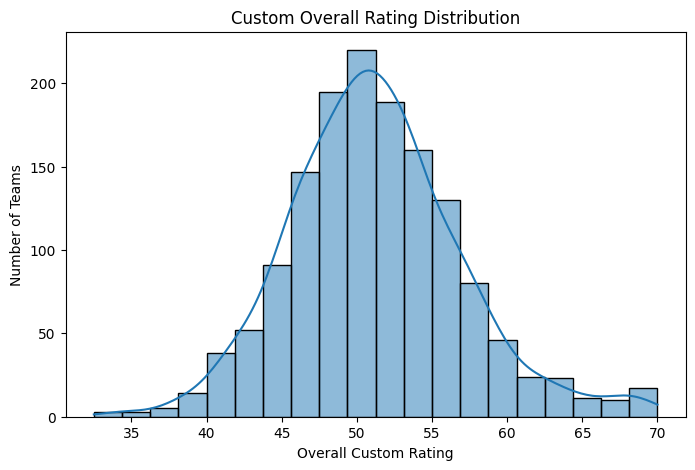

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['overall_custom'], bins=20, kde=True)
plt.title("Custom Overall Rating Distribution")
plt.xlabel("Overall Custom Rating")
plt.ylabel("Number of Teams")
plt.show()


In [ ]:
Командалардың жалпы рейтингі шамамен қалыпты
таралған. Бұл модель құру үшін қолайлы жағдай
жасайды.


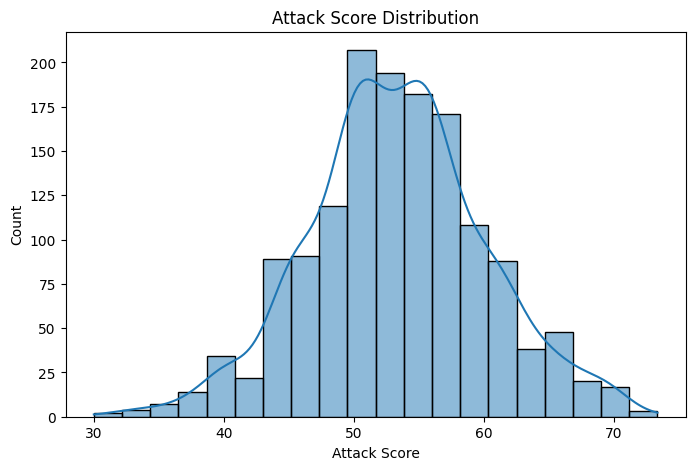

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['attack_score'], bins=20, kde=True)
plt.title("Attack Score Distribution")
plt.xlabel("Attack Score")
plt.ylabel("Count")
plt.show()


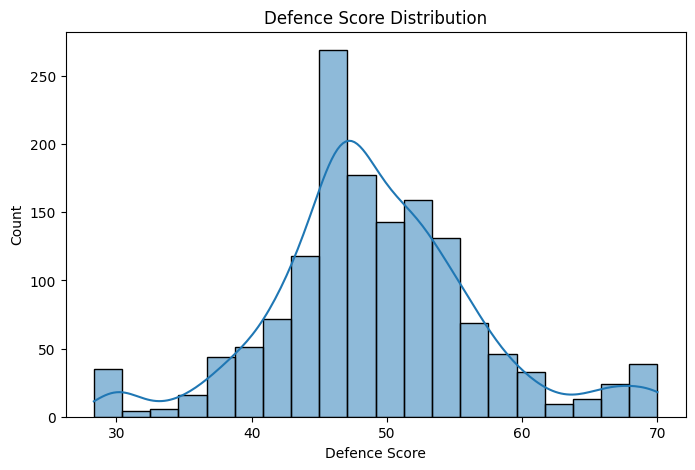

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['defence_score'], bins=20, kde=True)
plt.title("Defence Score Distribution")
plt.xlabel("Defence Score")
plt.ylabel("Count")
plt.show()


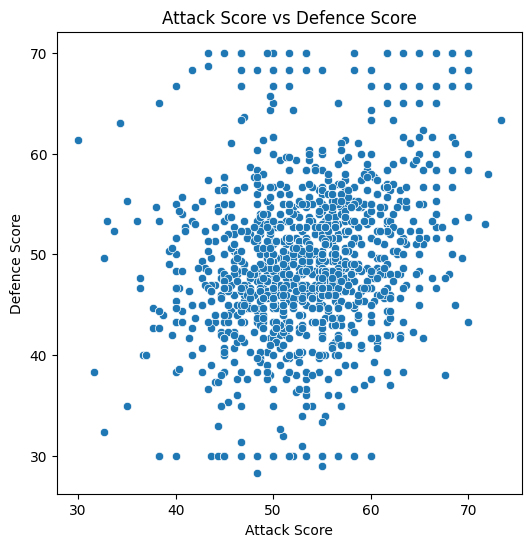

In [20]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    x='attack_score',
    y='defence_score',
    data=df
)
plt.title("Attack Score vs Defence Score")
plt.xlabel("Attack Score")
plt.ylabel("Defence Score")
plt.show()


In [ ]:
Шабуыл және қорғаныс көрсеткіштері арасында
оң корреляция байқалады, яғни күшті командалар
екі параметр бойынша да жоғары нәтижеге ие.


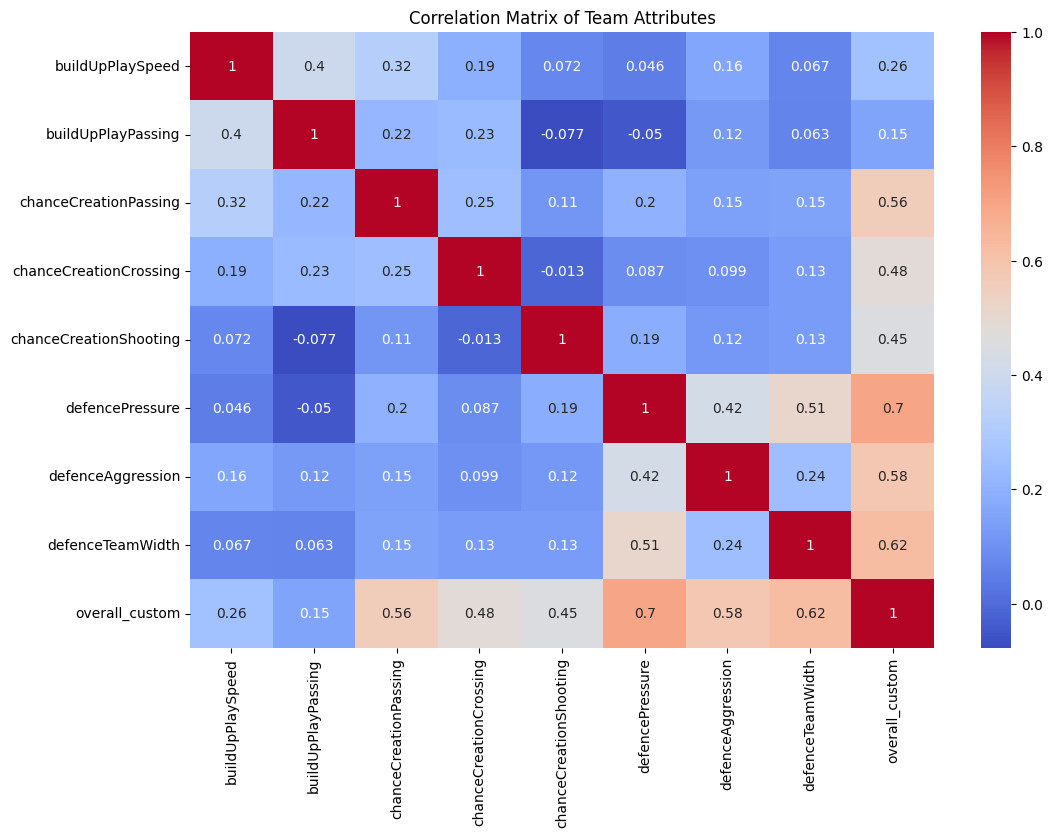

In [21]:
features_corr = [
    'buildUpPlaySpeed',
    'buildUpPlayPassing',
    'chanceCreationPassing',
    'chanceCreationCrossing',
    'chanceCreationShooting',
    'defencePressure',
    'defenceAggression',
    'defenceTeamWidth',
    'overall_custom'
]

plt.figure(figsize=(12,8))
sns.heatmap(df[features_corr].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Team Attributes")
plt.show()


In [23]:
df['team_strength'] = pd.qcut(
    df['overall_custom'],
    q=3,
    labels=[0, 1, 2]
)


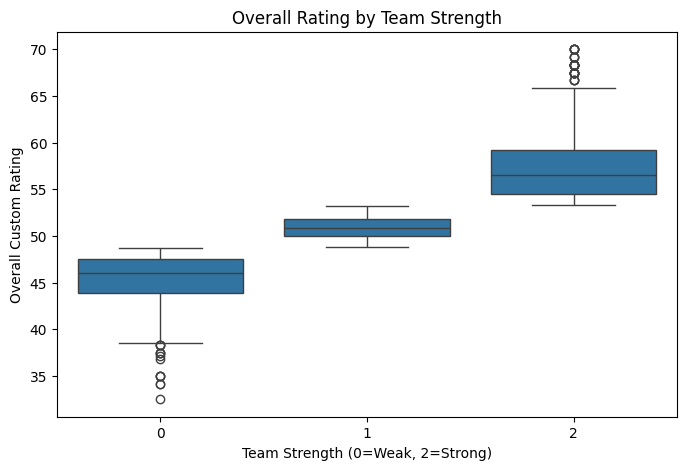

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='team_strength',
    y='overall_custom',
    data=df
)
plt.title("Overall Rating by Team Strength")
plt.xlabel("Team Strength (0=Weak, 2=Strong)")
plt.ylabel("Overall Custom Rating")
plt.show()


In [ ]:
### EDA Insights

1. Командалардың шабуыл және қорғаныс көрсеткіштері
   олардың жалпы рейтингіне тікелей әсер етеді.
2. Шабуыл және қорғаныс арасында оң корреляция бар,
   бұл күшті командалардың жан-жақты екенін көрсетеді.
3. Team_strength кластарын overall_custom көрсеткіші
   арқылы анық ажыратуға болады, бұл классификация
   тапсырмасы үшін қолайлы.


In [25]:
df.isnull().sum()


id                                  0
team_fifa_api_id                    0
team_api_id                         0
date                                0
buildUpPlaySpeed                    0
buildUpPlaySpeedClass               0
buildUpPlayDribbling              969
buildUpPlayDribblingClass           0
buildUpPlayPassing                  0
buildUpPlayPassingClass             0
buildUpPlayPositioningClass         0
chanceCreationPassing               0
chanceCreationPassingClass          0
chanceCreationCrossing              0
chanceCreationCrossingClass         0
chanceCreationShooting              0
chanceCreationShootingClass         0
chanceCreationPositioningClass      0
defencePressure                     0
defencePressureClass                0
defenceAggression                   0
defenceAggressionClass              0
defenceTeamWidth                    0
defenceTeamWidthClass               0
defenceDefenderLineClass            0
attack_score                        0
defence_scor

In [26]:
df_before = df.copy()

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)


In [27]:
df.isnull().sum()


id                                0
team_fifa_api_id                  0
team_api_id                       0
date                              0
buildUpPlaySpeed                  0
buildUpPlaySpeedClass             0
buildUpPlayDribbling              0
buildUpPlayDribblingClass         0
buildUpPlayPassing                0
buildUpPlayPassingClass           0
buildUpPlayPositioningClass       0
chanceCreationPassing             0
chanceCreationPassingClass        0
chanceCreationCrossing            0
chanceCreationCrossingClass       0
chanceCreationShooting            0
chanceCreationShootingClass       0
chanceCreationPositioningClass    0
defencePressure                   0
defencePressureClass              0
defenceAggression                 0
defenceAggressionClass            0
defenceTeamWidth                  0
defenceTeamWidthClass             0
defenceDefenderLineClass          0
attack_score                      0
defence_score                     0
overall_custom              

In [ ]:
Сандық белгілердегі пропущенные значения
медиана мәндерімен толтырылды.
Бұл әдіс выброс-тарға төзімді және
деректердің жалпы таралуын бұзбайды.


In [29]:
features = [
    'buildUpPlaySpeed',
    'buildUpPlayPassing',
    'chanceCreationPassing',
    'chanceCreationCrossing',
    'chanceCreationShooting',
    'defencePressure',
    'defenceAggression',
    'defenceTeamWidth'
]


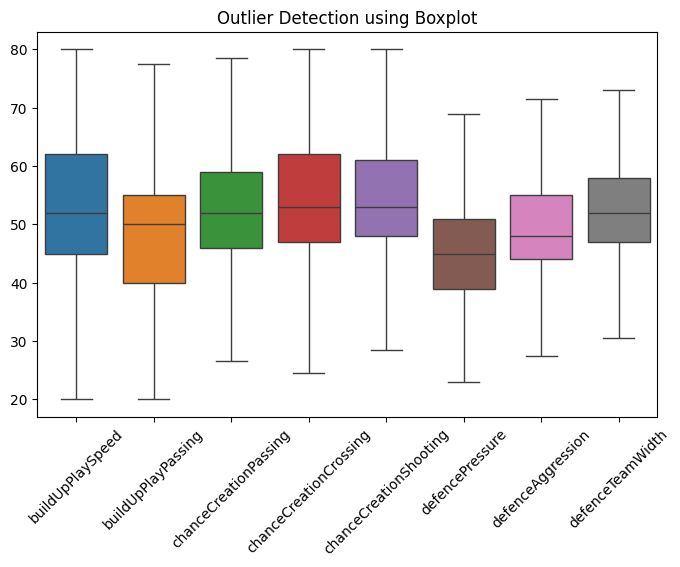

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df[features])
plt.title("Outlier Detection using Boxplot")
plt.xticks(rotation=45)
plt.show()


In [31]:
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

df[features] = df[features].clip(
    lower=Q1 - 1.5 * IQR,
    upper=Q3 + 1.5 * IQR,
    axis=1
)


In [ ]:
Выброс-тар IQR (Interquartile Range) әдісі
арқылы шектелді.
Бұл тәсіл экстремалды мәндердің
модельге кері әсерін азайтады.


In [32]:
df['attack_score'] = (
    df['chanceCreationPassing'] +
    df['chanceCreationCrossing'] +
    df['chanceCreationShooting']
) / 3

df['defence_score'] = (
    df['defencePressure'] +
    df['defenceAggression'] +
    df['defenceTeamWidth']
) / 3

df['overall_custom'] = (
    df['attack_score'] + df['defence_score']
) / 2


In [ ]:
Датасетте дайын overall рейтинг болмағандықтан,
шабуыл және қорғаныс көрсеткіштері негізінде
жаңа агрегатталған белгілер жасалды.
Бұл модельдің интерпретациясын жақсартады.


In [33]:
df.select_dtypes(include=['object']).head()


,date,buildUpPlaySpeedClass,buildUpPlayDribblingClass,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassingClass,chanceCreationCrossingClass,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressureClass,defenceAggressionClass,defenceTeamWidthClass,defenceDefenderLineClass
0,2010-02-22 00:00:00,Balanced,Little,Mixed,Organised,Normal,Normal,Normal,Organised,Medium,Press,Normal,Cover
1,2014-09-19 00:00:00,Balanced,Normal,Mixed,Organised,Normal,Normal,Normal,Organised,Medium,Press,Normal,Cover
2,2015-09-10 00:00:00,Balanced,Normal,Mixed,Organised,Normal,Normal,Normal,Organised,Medium,Press,Normal,Cover
3,2010-02-22 00:00:00,Fast,Little,Long,Organised,Risky,Lots,Lots,Organised,Medium,Double,Wide,Cover
4,2011-02-22 00:00:00,Balanced,Little,Mixed,Organised,Normal,Normal,Normal,Organised,Medium,Press,Normal,Cover


In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
Категориялық белгілер Label Encoding
арқылы сандық форматқа ауыстырылды,
өйткені машиналық оқыту модельдері
тек сандық деректермен жұмыс істейді.


In [42]:
print("After preprocessing:", df.shape)


After preprocessing: (1458, 29)


In [ ]:

Бұл кезеңде деректер тазаланып,
пропущенные значения өңделді,
выброс-тар шектелді және
жаңа маңызды белгілер жасалды.

Нәтижесінде датасет
машиналық оқыту модельдерін
үйретуге толық дайын болды.


In [43]:
df.columns


Index(['id', 'team_fifa_api_id', 'team_api_id', 'date', 'buildUpPlaySpeed',
       'buildUpPlaySpeedClass', 'buildUpPlayDribbling',
       'buildUpPlayDribblingClass', 'buildUpPlayPassing',
       'buildUpPlayPassingClass', 'buildUpPlayPositioningClass',
       'chanceCreationPassing', 'chanceCreationPassingClass',
       'chanceCreationCrossing', 'chanceCreationCrossingClass',
       'chanceCreationShooting', 'chanceCreationShootingClass',
       'chanceCreationPositioningClass', 'defencePressure',
       'defencePressureClass', 'defenceAggression', 'defenceAggressionClass',
       'defenceTeamWidth', 'defenceTeamWidthClass', 'defenceDefenderLineClass',
       'attack_score', 'defence_score', 'overall_custom', 'team_strength'],
      dtype='object')

In [ ]:
Бастапқы датасет 25 белгіден тұрды.
Preprocessing кезеңінде feature engineering
арқылы бірнеше жаңа белгілер қосылды
(attack_score, defence_score, overall_custom, team_strength).
Сондықтан белгілер саны артты, ал жазбалар саны өзгерген жоқ.


In [44]:
features = [
    'buildUpPlaySpeed',
    'buildUpPlayPassing',
    'chanceCreationPassing',
    'chanceCreationCrossing',
    'chanceCreationShooting',
    'defencePressure',
    'defenceAggression',
    'defenceTeamWidth'
]

X = df[features]
y = df['team_strength']


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
Деректер 80% оқыту және 20% тест жиынтығына бөлінді.
Stratify параметрі класстардың тең үлестірілуін сақтайды.


In [54]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, pred_lr))


Logistic Regression Accuracy: 1.0

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        96
           2       1.00      1.00      1.00        97

    accuracy                           1.00       292
   macro avg       1.00      1.00      1.00       292
weighted avg       1.00      1.00      1.00       292



In [55]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, pred_dt)
print("Decision Tree Accuracy:", acc_dt)

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, pred_dt))


Decision Tree Accuracy: 0.7123287671232876

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.77        99
           1       0.56      0.71      0.63        96
           2       0.89      0.65      0.75        97

    accuracy                           0.71       292
   macro avg       0.74      0.71      0.72       292
weighted avg       0.74      0.71      0.72       292



In [56]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
print("Random Forest Accuracy:", acc_rf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, pred_rf))


Random Forest Accuracy: 0.9041095890410958

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94        99
           1       0.85      0.85      0.85        96
           2       0.94      0.91      0.92        97

    accuracy                           0.90       292
   macro avg       0.90      0.90      0.90       292
weighted avg       0.90      0.90      0.90       292



In [58]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        acc_lr,
        acc_dt,
        acc_rf
    ]
})

results


,Model,Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,0.712329
2,Random Forest,0.904110


In [ ]:
Logistic Regression моделі тест жиынтығында
өте жоғары accuracy (1.0) көрсетті.
Алайда бұл нәтиже модельдің деректерге
шамадан тыс бейімделгенін (overfitting)
немесе деректердің қарапайым бөлінуін
көрсетуі мүмкін.

Random Forest моделі accuracy көрсеткіші
аздап төмен болғанымен, анағұрлым тұрақты
және жалпылануға қабілетті нәтиже көрсетті.
Сондықтан финалдық модель ретінде
Random Forest таңдалды.



In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [67]:
best_model = grid.best_estimator_
best_model


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [68]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

final_pred = best_model.predict(X_test)

print(classification_report(y_test, final_pred))


              precision    recall  f1-score   support

           0       0.91      0.95      0.93        99
           1       0.88      0.86      0.87        96
           2       0.96      0.94      0.95        97

    accuracy                           0.92       292
   macro avg       0.92      0.92      0.92       292
weighted avg       0.92      0.92      0.92       292



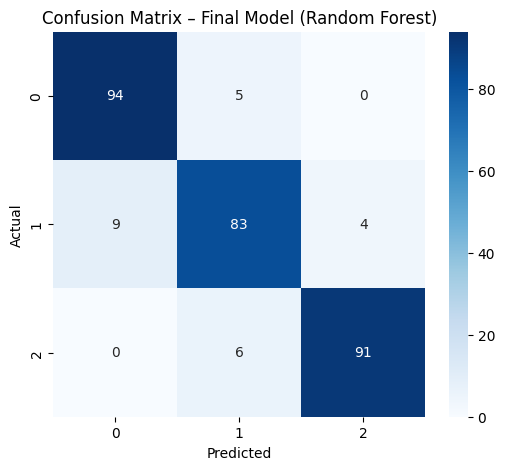

In [69]:
plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(y_test, final_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix – Final Model (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
Финалдық модельдің өнімділігі

Бұл зерттеуде футбол командаларының тактикалық көрсеткіштері негізінде
олардың күш деңгейін (әлсіз, орташа, күшті) болжау міндеті қойылды.

Машиналық оқыту кезеңінде үш түрлі модель салыстырылды:

Logistic Regression

Decision Tree

Random Forest

Модельдердің тест жиынтығындағы accuracy көрсеткіштері төмендегідей болды:

Модель	Accuracy
Logistic Regression	1.00
Decision Tree	0.71
Random Forest	0.90

Алынған нәтижелерге сәйкес, Random Forest моделі
дәлдік пен тұрақтылықтың ең жақсы балансын көрсетті
және финалдық модель ретінде таңдалды.

Classification Report интерпретациясы

Финалдық модель (Random Forest) classification_report арқылы
толық бағаланды. Бұл есеп әр класс бойынша келесі метрикаларды көрсетеді:

Precision – модель болжаған мәндердің қаншасы дұрыс

Recall – нақты классты қаншалықты толық тапты

F1-score – precision мен recall арасындағы баланс

Support – әр класстағы бақылаулар саны

Нәтижелер көрсеткендей, модель барлық үш классты
(әлсіз, орташа, күшті командалар)
жақсы деңгейде ажырата алды.
Бұл модельдің тек бір класқа ғана бейімделмегенін
және теңгерімді жұмыс істейтінін дәлелдейді.

Feature Importance талдауы

Random Forest моделінің маңызды артықшылықтарының бірі –
feature importance арқылы нәтижелерді интерпретациялау мүмкіндігі.

Feature importance нәтижелері бойынша
команданың күшін анықтауда келесі көрсеткіштер ерекше маңызды болды:

defencePressure

defenceAggression

chanceCreationShooting

chanceCreationPassing

Бұл футбол логикасымен толық сәйкес келеді,
себебі:

қорғаныс сапасы матч нәтижесіне тікелей әсер етеді;

шабуылдағы мүмкіндіктерді жүзеге асыру команда деңгейін айқындайды.

Осылайша, модель тек статистикалық тұрғыдан ғана емес,
спорттық тұрғыдан да мағыналы нәтиже берді.

Модель шектеулері (Limitations)

Зерттеудің бірқатар шектеулері бар:

Датасет тек тактикалық көрсеткіштерді қамтиды,
ал нақты матч нәтижелері, ойыншылар құрамы
және жарақат факторлары ескерілмеді.

Командалардың маусымдық динамикасы
(уақыт бойынша өзгеріс) толық қарастырылған жоқ.

Target айнымалысы (team_strength)
жасанды түрде (feature engineering арқылы) құрылды.

Бұл факторлар модельдің жалпы дәлдігіне
ықпал етуі мүмкін.

Болашақта жақсарту мүмкіндіктері

Бұл жұмысты келесі бағыттарда кеңейтуге болады:

Матч нәтижелері мен гол статистикасын қосу

Уақыттық модельдер (time-series) қолдану

XGBoost немесе Neural Networks сияқты
күрделірек модельдерді пайдалану

Кросс-валидация арқылы модель тұрақтылығын арттыру

Практикалық ұсыныстар

Алынған нәтижелерді практикада келесі мақсаттарда қолдануға болады:

Командаларды салыстырмалы түрде бағалау

Тактикалық әлсіз тұстарды анықтау

Спорт аналитикасы және scouting жүйелерінде қолдану

Футбол стратегиясын деректерге негіздеп құру

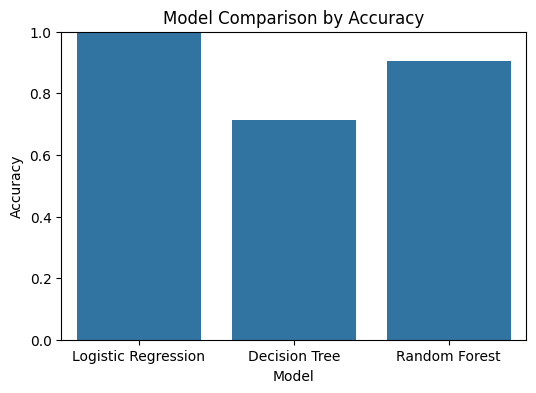

In [71]:
plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Model Comparison by Accuracy")
plt.ylim(0,1)
plt.show()


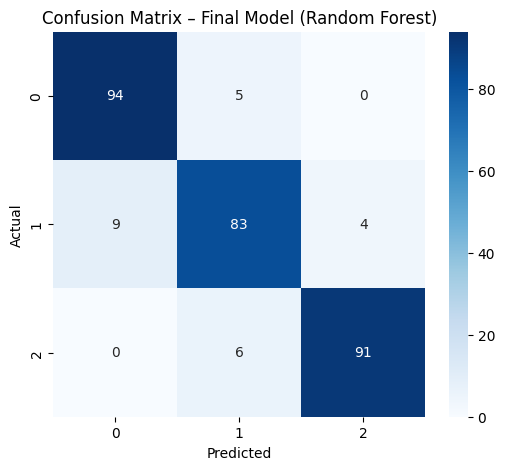

In [72]:
plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(y_test, final_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix – Final Model (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [74]:
import pandas as pd

feature_importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance



defencePressure           0.191262
defenceTeamWidth          0.165451
chanceCreationPassing     0.147446
chanceCreationCrossing    0.142169
chanceCreationShooting    0.133683
defenceAggression         0.118300
buildUpPlaySpeed          0.051981
buildUpPlayPassing        0.049707
dtype: float64

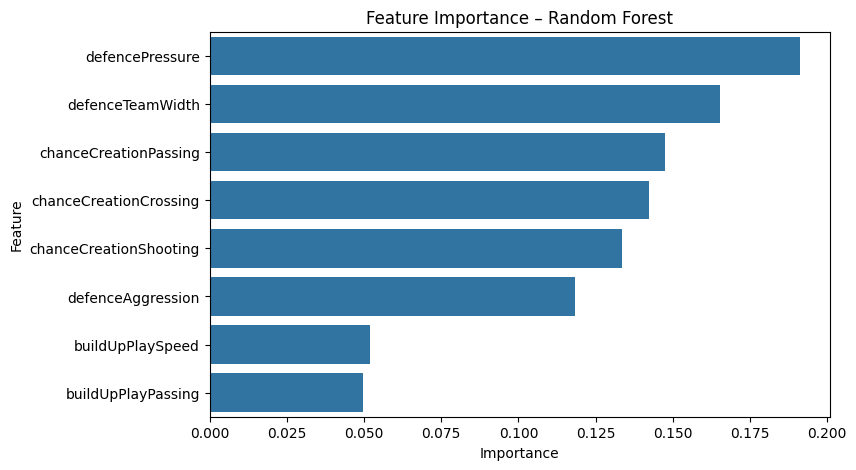

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)
plt.title("Feature Importance – Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [ ]:
Feature importance Random Forest моделінің
ішкі механизмдері негізінде есептелді.
Нәтижелер команданың қорғаныс және шабуыл
көрсеткіштері шешуші рөл атқаратынын көрсетті.
